# S_RiskMap: County-Level Origin Risk (3 panels)

Three vertically stacked maps showing simulated outbreak outcomes when each dairy county is seeded as the origin:
- **Panel A**: Multi-state spread probability (% of simulations reaching ≥3 states), with labeled epicenter counties
- **Panel B**: Median number of states reached, with epicenter county borders only
- **Panel C**: Median number of counties reached, with epicenter county borders only

**Data:** `all_county_origins/scenario_summary.csv` (2,504 counties, 75,000 sims each)

**Output:** `S_RiskMap.png/.pdf`

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
FIG_DIR = FINAL_DIR / 'figures'
LEGACY_FIG_DIR = PAPER_DIR / 'figures'

EPICENTER_COUNTIES = {
    48069: ('Castro', 'TX', '#d62728', '*', 250),
    48341: ('Moore', 'TX', '#ff7f00', 's', 120),
    48117: ('Deaf Smith', 'TX', '#2ca02c', 'D', 100),
    35009: ('Curry', 'NM', '#17becf', '^', 100),
    37183: ('Wake', 'NC', '#7f7f7f', 'v', 100),
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ──
scenario = pd.read_csv(LEGACY_FIG_DIR / 'all_county_origins' / 'scenario_summary.csv')
scenario['pct_establishment_3'] = 100 - scenario['pct_leq_2_states']
print(f'Scenario data: {len(scenario)} counties')

# Load GADM county shapefile + FIPS lookup
RAW_DIR = PAPER_DIR.parent / 'analysis' / 'H5N1-Simulations-and-Analysis' / 'data' / 'raw'
gdf = gpd.read_file(RAW_DIR / 'gadm41_USA_shp' / 'gadm41_USA_2.shp')
fips_lookup = pd.read_csv(RAW_DIR / 'US_FIPS_Codes_formatted.csv')

def norm(s):
    return s.lower().replace('saint ', 'st. ').replace('sainte ', 'ste. ').replace('dekalb', 'de kalb')

gdf['join_key'] = gdf['NAME_1'].apply(norm) + '|' + gdf['NAME_2'].apply(norm)
fips_lookup['join_key'] = fips_lookup['state'].apply(norm) + '|' + fips_lookup['county'].apply(norm)
gdf = gdf.merge(fips_lookup[['join_key', 'fips']], on='join_key', how='left')

exclude_states = ['Alaska', 'Hawaii', 'Guam', 'American Samoa',
                  'Northern Mariana Islands', 'Puerto Rico', 'U.S. Virgin Islands']
gdf = gdf[~gdf['NAME_1'].isin(exclude_states)]
gdf['fips_int'] = gdf['fips'].astype('Int64')

# Merge all outcome columns
merge_cols = ['seed_county', 'pct_establishment_3', 'median_states', 'median_counties']
gdf = gdf.merge(scenario[merge_cols], left_on='fips_int', right_on='seed_county', how='left')
gdf['is_dairy'] = gdf['pct_establishment_3'].notna()

state_boundaries = gdf.dissolve(by='NAME_1').boundary
print(f'GADM counties: {len(gdf)}, dairy: {gdf["is_dairy"].sum()}')

# Epicenter centroids
epic_centroids = {}
for fips in EPICENTER_COUNTIES:
    epic_geo = gdf[gdf['fips_int'] == fips]
    if len(epic_geo) > 0:
        epic_centroids[fips] = epic_geo.geometry.centroid.iloc[0]

# Label order (Castro/Deaf Smith swapped to prevent line crossing)
sorted_fips = sorted(epic_centroids.keys(), key=lambda f: epic_centroids[f].x, reverse=True)
idx_castro = sorted_fips.index(48069)
idx_deaf = sorted_fips.index(48117)
sorted_fips[idx_castro], sorted_fips[idx_deaf] = sorted_fips[idx_deaf], sorted_fips[idx_castro]

Scenario data: 2504 counties
GADM counties: 3117, dairy: 2502


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_3912/3428985693.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  epic_centroids[fips] = epic_geo.geometry.centroid.iloc[0]
/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_3912/3428985693.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  epic_centroids[fips] = epic_geo.geometry.centroid.iloc[0]
/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_3912/3428985693.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  epic_centroids[fips] = epic_geo.geometry.centroid.iloc[0]
/var/folders/ls/3sw

Establishment: 0.0%–100.0%, median 11.2%
States reached: 1–38, median 1
Counties reached: 1–523, median 1


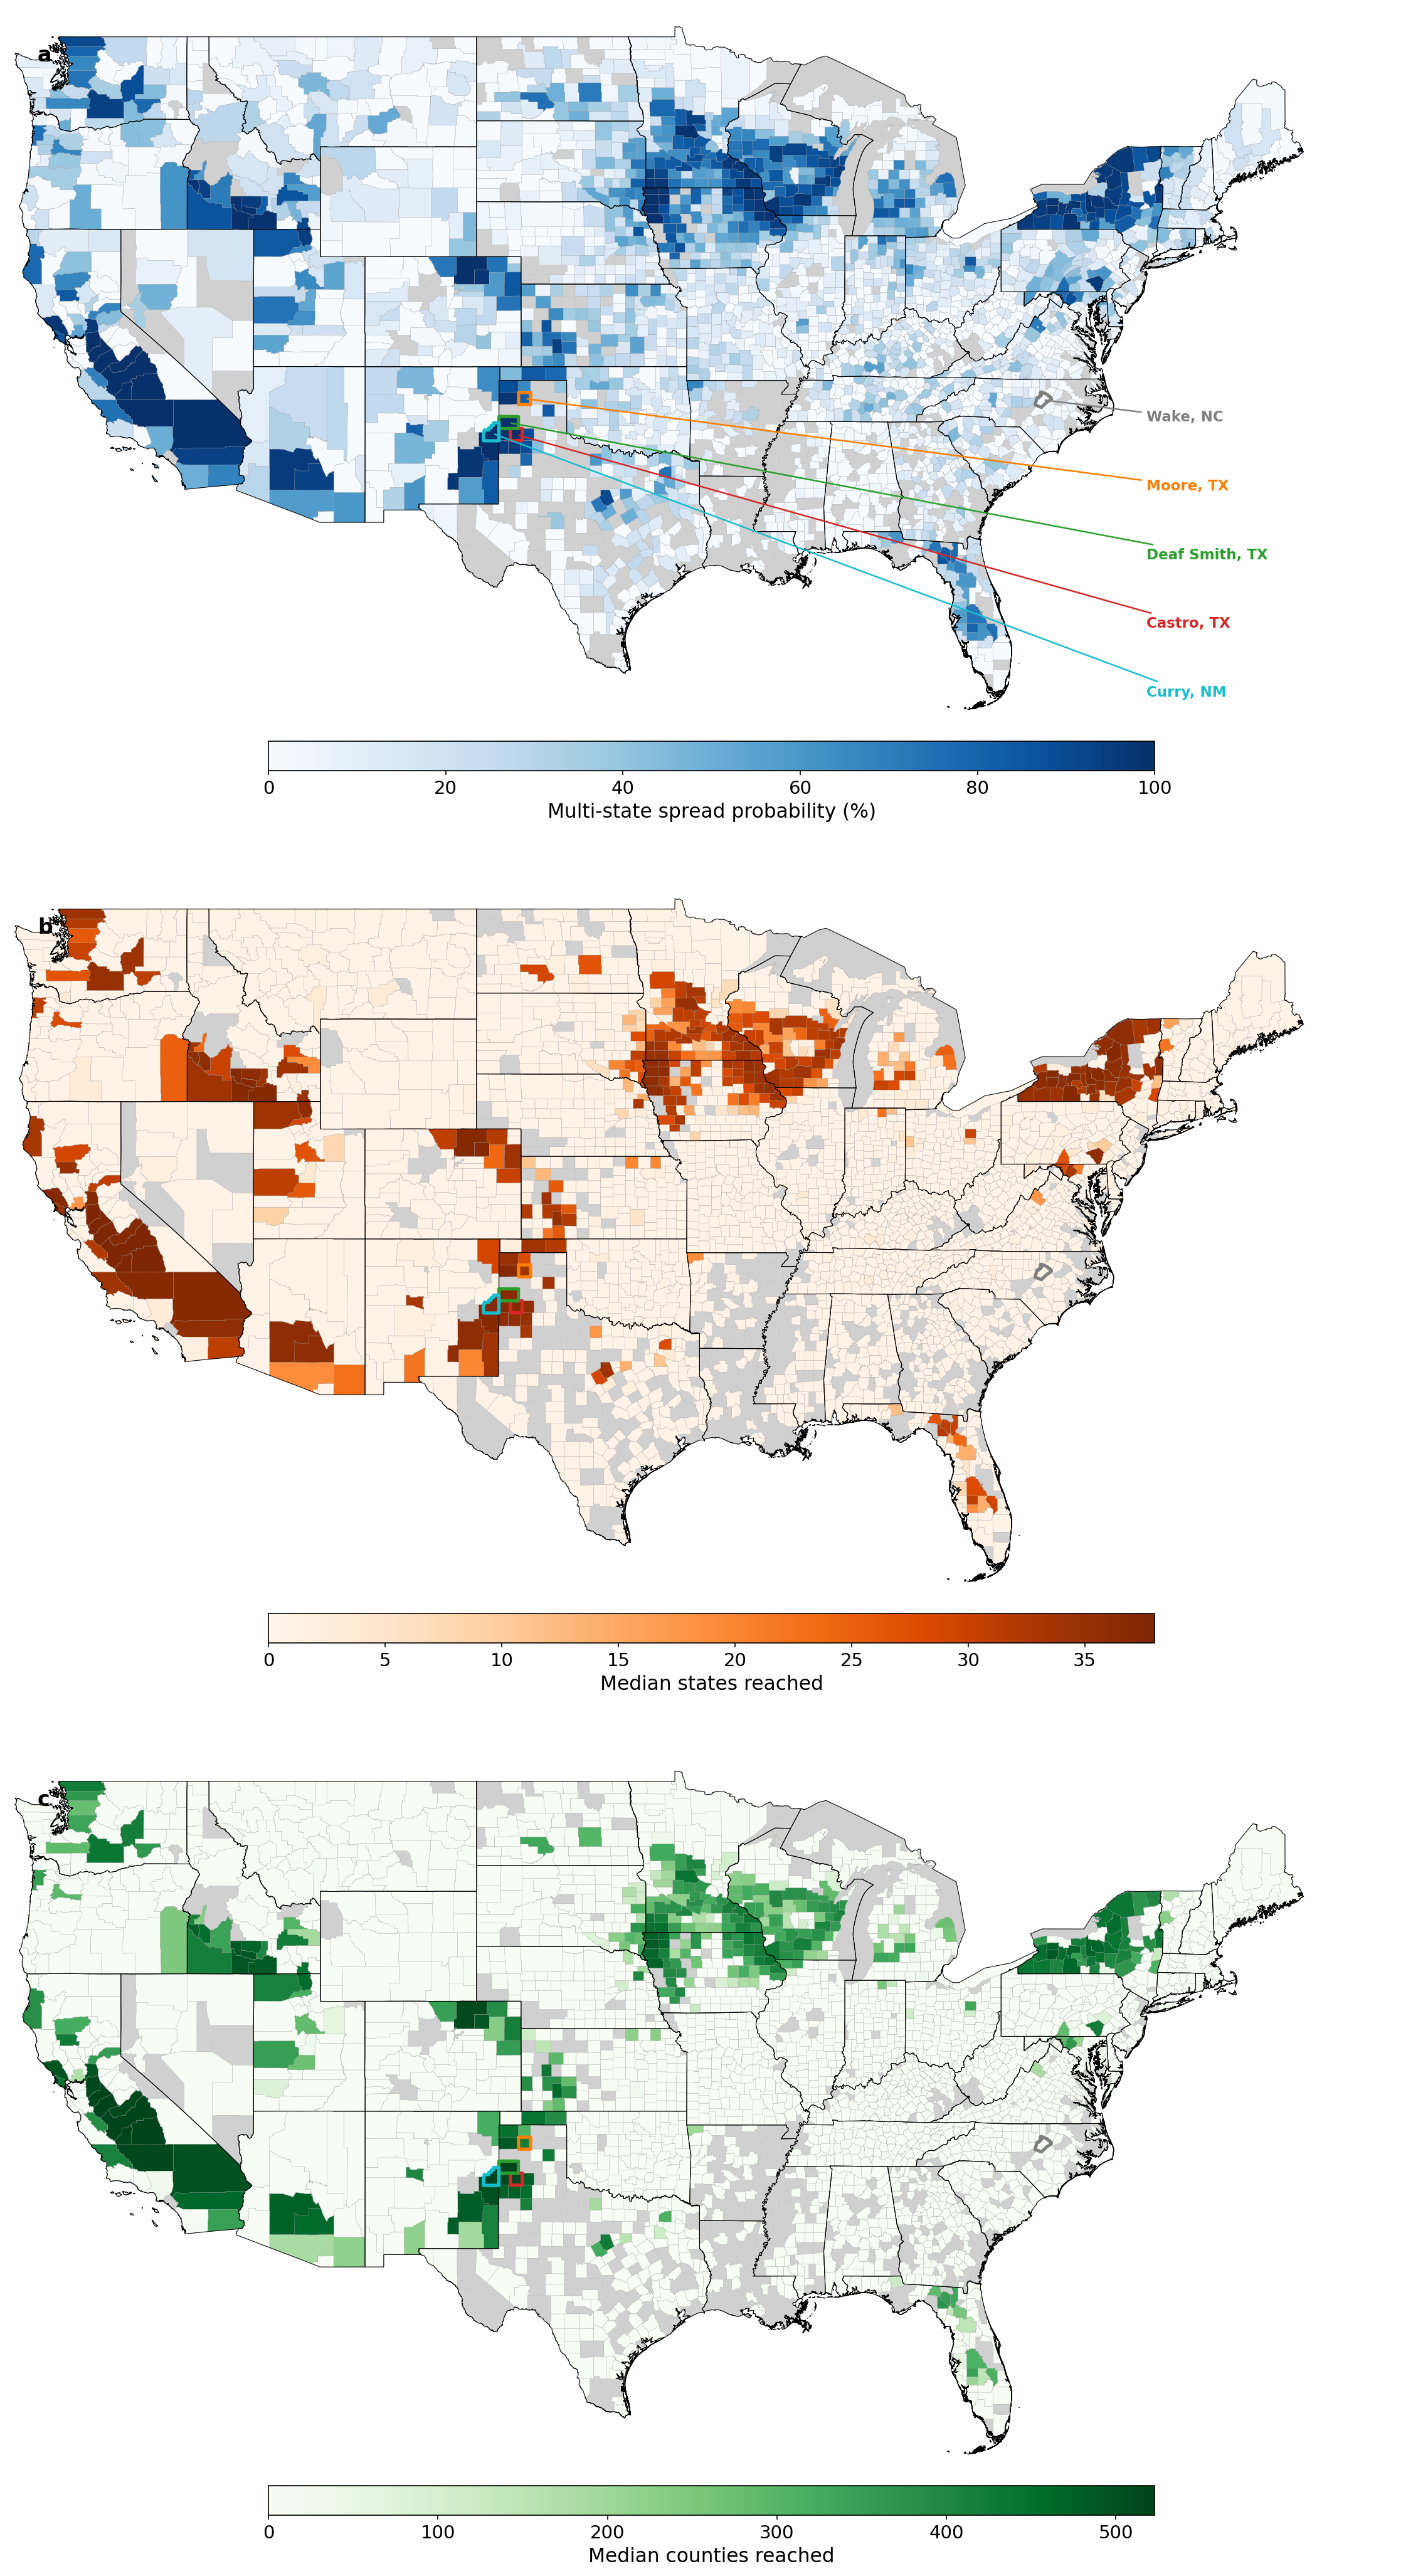

In [3]:
# ── 3-panel risk map ──
cmap_estab = LinearSegmentedColormap.from_list('risk',
    ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6',
     '#4292c6', '#2171b5', '#08519c', '#08306b'])
cmap_states = LinearSegmentedColormap.from_list('states',
    ['#fff5eb', '#fee6ce', '#fdd0a2', '#fdae6b', '#fd8d3c',
     '#f16913', '#d94801', '#a63603', '#7f2704'])
cmap_counties = LinearSegmentedColormap.from_list('counties',
    ['#f7fcf5', '#e5f5e0', '#c7e9c0', '#a1d99b', '#74c476',
     '#41ab5d', '#238b45', '#006d2c', '#00441b'])

NON_DAIRY_COLOR = '#D0D0D0'

dairy = gdf[gdf['is_dairy']].copy()

panels = [
    ('pct_establishment_3', cmap_estab, 0, 100, 'Multi-state spread probability (%)'),
    ('median_states', cmap_states, 0, dairy['median_states'].max(), 'Median states reached'),
    ('median_counties', cmap_counties, 0, dairy['median_counties'].max(), 'Median counties reached'),
]

fig_map, axes_map = plt.subplots(3, 1, figsize=(16, 28))

for panel_idx, (col, cmap, vmin, vmax, cbar_label) in enumerate(panels):
    ax = axes_map[panel_idx]

    gdf[~gdf['is_dairy']].plot(ax=ax, color=NON_DAIRY_COLOR, edgecolor='#BBBBBB', linewidth=0.1)

    dairy.plot(ax=ax, column=col, cmap=cmap, edgecolor='#999999', linewidth=0.15,
               vmin=vmin, vmax=vmax, legend=True,
               legend_kwds={'label': cbar_label, 'orientation': 'horizontal',
                            'shrink': 0.6, 'pad': 0.02, 'aspect': 30})

    cbar_ax = fig_map.axes[-1]
    cbar_ax.tick_params(labelsize=14)
    cbar_ax.set_xlabel(cbar_ax.get_xlabel(), fontsize=15)
    existing_ticks = list(cbar_ax.get_xticks())
    if 0 not in existing_ticks:
        existing_ticks = [0] + existing_ticks
        cbar_ax.set_xticks(existing_ticks)

    state_boundaries.plot(ax=ax, color='black', linewidth=0.5, zorder=4)

    for fips in EPICENTER_COUNTIES:
        name, st, color, marker, ms = EPICENTER_COUNTIES[fips]
        epic_geo = gdf[gdf['fips_int'] == fips]
        if len(epic_geo) > 0:
            epic_geo.plot(ax=ax, facecolor='none', edgecolor=color, linewidth=2.5, zorder=8)

    if panel_idx == 0:
        label_y_top = 35
        label_y_bottom = 25
        label_x = -74
        label_ys = np.linspace(label_y_top, label_y_bottom, len(sorted_fips))
        for fips, label_y in zip(sorted_fips, label_ys):
            name, st, color, marker, ms = EPICENTER_COUNTIES[fips]
            centroid = epic_centroids[fips]
            ax.annotate(f'{name}, {st}', xy=(centroid.x, centroid.y),
                        xytext=(label_x, label_y), fontsize=11, fontweight='bold',
                        color=color, arrowprops=dict(arrowstyle='-', color=color, lw=1.2),
                        zorder=12)

    ax.set_xlim(-125, -62)
    ax.set_ylim(24, 50)
    ax.set_axis_off()

    ax.text(0.02, 0.95, chr(ord('a') + panel_idx), transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top')

fig_map.tight_layout(h_pad=2)
# fig_map.savefig(FIG_DIR / 'S_RiskMap.png', dpi=300, bbox_inches='tight')
# fig_map.savefig(FIG_DIR / 'S_RiskMap.pdf', bbox_inches='tight')

# print(f'\nS_RiskMap saved (3 panels). {len(dairy)} dairy counties.')
print(f'Establishment: {dairy.pct_establishment_3.min():.1f}%–{dairy.pct_establishment_3.max():.1f}%, median {dairy.pct_establishment_3.median():.1f}%')
print(f'States reached: {dairy.median_states.min():.0f}–{dairy.median_states.max():.0f}, median {dairy.median_states.median():.0f}')
print(f'Counties reached: {dairy.median_counties.min():.0f}–{dairy.median_counties.max():.0f}, median {dairy.median_counties.median():.0f}')
plt.show()